# Epsilon-Selection Stage Position Study

This notebook presents the experimental study conducted to evaluate the impact of the position of the $\varepsilon$-selection step in the proposed near-equivalent Q-learning framework using the simulated cancer DTR setting.

## 1. Imports

The companion script contains the full experiment plan and the plotting functions.

In [1]:
import importlib
import sys
sys.path.append("scripts")
from DTR_epsilon_selection_experiment import *
from IPython.display import display

## 2. Experiment configuration and running

In [2]:
config = ExperimentConfig(
    n_train=2000,
    n_test=1000,
    n_replications=10,
    epsilon_selection=0.3,
    t_values=[5, 7, 8, 9, 10, 12],
    c0_death=-12.0,
    seed=42,
    scripts_dir="scripts",
    results_dir="results",
)

config

results = run_experiment_plan(config, verbose=True)


RUNNING COMPLETE EXPERIMENT PLAN
T horizons : [5, 7, 8, 9, 10, 12]
Replications: 10
Results dir: results

[1/6] Running T_final = 5
   done | mean admissible = 4.44 | singleton = 19.9%

[2/6] Running T_final = 7
   done | mean admissible = 5.11 | singleton = 20.2%

[3/6] Running T_final = 8
   done | mean admissible = 5.32 | singleton = 18.5%

[4/6] Running T_final = 9
   done | mean admissible = 6.10 | singleton = 15.0%

[5/6] Running T_final = 10
   done | mean admissible = 6.49 | singleton = 11.4%

[6/6] Running T_final = 12
   done | mean admissible = 7.79 | singleton = 6.2%

EXPERIMENT PLAN COMPLETED
Saved files:
  - comparison_summary_by_T.csv
  - comparison_qscale_by_T.csv
  - comparison_pct_by_T.csv
  - comparison_final_stage_by_T.csv


## 3. Load saved results

In [2]:
results = load_experiment_results(results_dir="results")

comparison_summary = results["comparison_summary"]
comparison_qscale = results["comparison_qscale"]
final_stage_comparison = results["final_stage_comparison"]

## 4. Tables results

In [3]:
epsilon_stage_comparison = (
    comparison_summary[
        [
            "T_final",
            "c0_death",
            "epsilon_selection",
            "stage",
            "relative_stage",
            "mean_n_admissible_mean",
            "mean_n_admissible_sd",
            "pct_1_treatment_mean",
            "pct_all_treatments_mean",
        ]
    ]
    .sort_values(["T_final", "stage"])
    .reset_index(drop=True)
)

epsilon_stage_comparison

,T_final,c0_death,epsilon_selection,stage,relative_stage,mean_n_admissible_mean,mean_n_admissible_sd,pct_1_treatment_mean,pct_all_treatments_mean
0,5,-12.0,0.3,1,0.000000,4.1194,0.285624,0.00,6.40
1,5,-12.0,0.3,2,0.250000,5.7147,0.402632,0.10,24.81
2,5,-12.0,0.3,3,0.500000,4.9050,0.372193,2.52,20.16
3,5,-12.0,0.3,4,0.750000,5.3823,0.670831,10.10,30.44
4,5,-12.0,0.3,5,1.000000,4.4436,0.657232,19.89,23.03
5,7,-12.0,0.3,1,0.000000,4.4578,0.379755,0.00,7.91
6,7,-12.0,0.3,2,0.166667,6.2483,0.517249,0.00,32.64
7,7,-12.0,0.3,3,0.333333,5.3720,0.357956,1.60,24.56
8,7,-12.0,0.3,4,0.500000,6.0617,0.207966,7.86,38.03
9,7,-12.0,0.3,5,0.666667,5.8809,0.457614,14.24,39.09


(<Figure size 960x600 with 2 Axes>,
 (<Axes: xlabel='Final horizon $T$', ylabel='Mean number of admissible treatments'>,
  <Axes: ylabel='Singleton recommendations (%)'>))

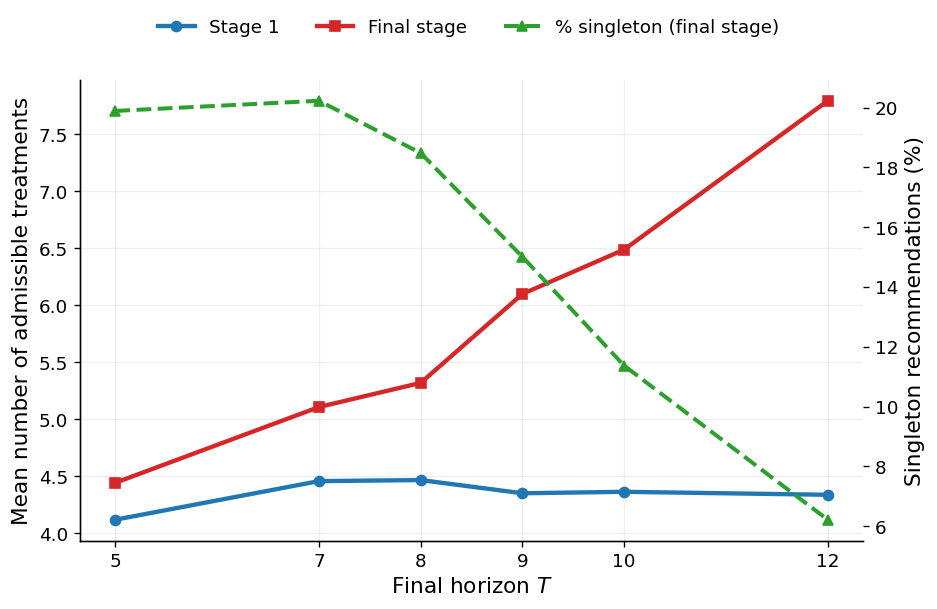

In [4]:
plot_horizon_effect_summary(
    epsilon_stage_comparison,
    output_path=os.path.join(
        "results",
        "horizon_effect_summary.pdf"
    )
)

## 5. Figures — Mean number of admissible treatments and Mean top-2 Q-value gap

The first figure shows how the stage at which epsilon-selection is applied changes the size of the admissible treatment set. The x-axis is normalized to compare horizons of different lengths. 

The second figure diagnoses the separation between the best and second-best treatment-specific Q-values. Smaller gaps indicate weaker treatment discrimination.

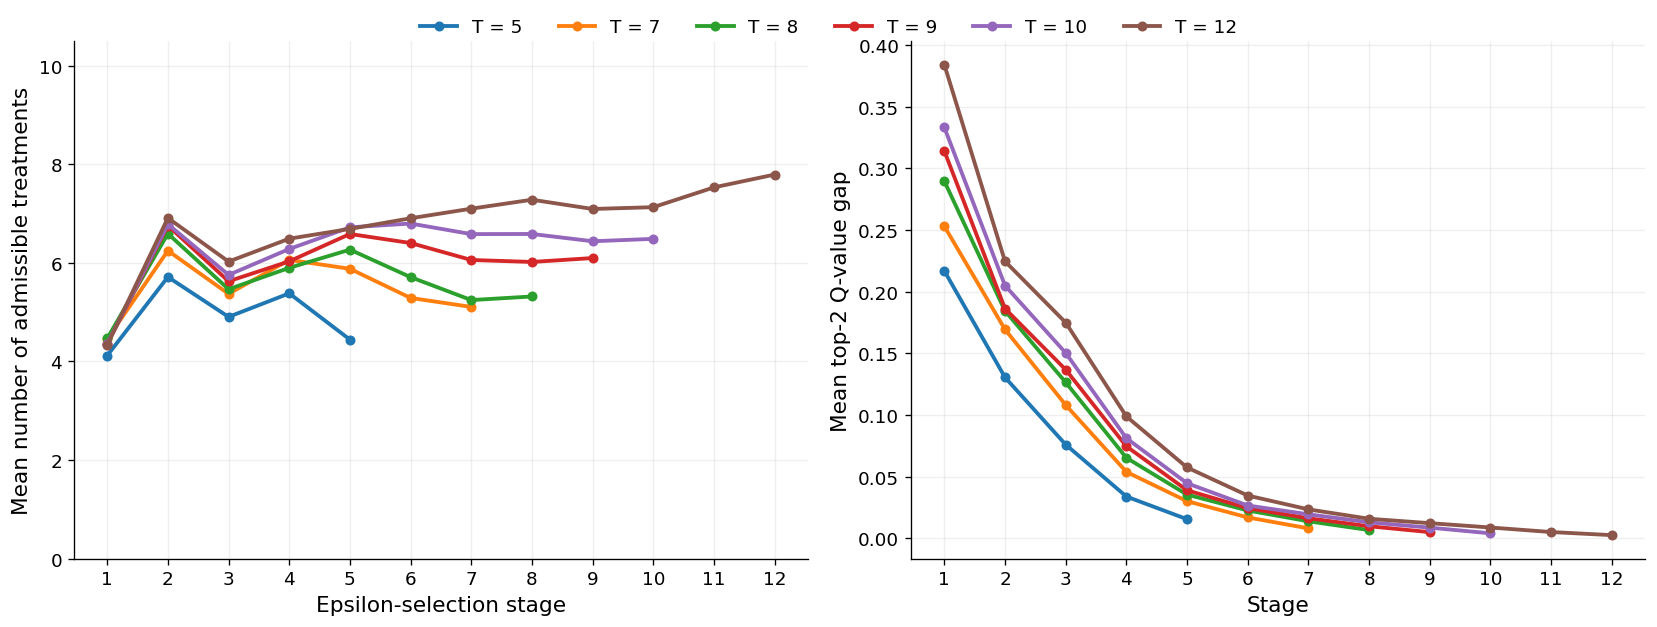

In [5]:
plot_main_results_side_by_side(
    comparison_summary,
    comparison_qscale,
    use_relative_stage=False,
    output_path="results/main_results.pdf"
);